In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.preprocessing import image

# Train / Validate / Test Dataset 

In [2]:
IMG_SIZE = (224, 224)
train_dir = r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Data\Covid19-dataset\train"
test_dir = r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Data\Covid19-dataset\test"

train_dataset = image_dataset_from_directory(
                                                train_dir,
                                                validation_split=0.2,   # 20% for validation
                                                subset="training",
                                                seed=42,
                                                image_size=IMG_SIZE,
                                                batch_size=32
                                            )

val_dataset = image_dataset_from_directory(
                                                train_dir,
                                                validation_split=0.2,
                                                subset="validation",
                                                seed=42,
                                                image_size=IMG_SIZE,
                                                batch_size=32
                                            )

test_dataset = image_dataset_from_directory(
                                                test_dir,
                                                image_size=IMG_SIZE,
                                                batch_size=32
                                            )

Found 251 files belonging to 3 classes.
Using 201 files for training.


Found 251 files belonging to 3 classes.
Using 50 files for validation.
Found 66 files belonging to 3 classes.


In [3]:
class_names=train_dataset.class_names
n_classes=len(class_names)
print(class_names)
print(n_classes)

['Covid', 'Normal', 'Viral Pneumonia']
3


In [4]:
def image_resize_and_rescale(img):
  img=img/255.0
  img=tf.image.resize(img,[224,224])
  return img

train_dataset=train_dataset.map(lambda x,y: (image_resize_and_rescale(x),y))
val_dataset=val_dataset.map(lambda x,y: (image_resize_and_rescale(x),y))
test_dataset=test_dataset.map(lambda x,y: (image_resize_and_rescale(x),y))


In [8]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
                                            tf.keras.layers.RandomRotation(0.05),
                                            tf.keras.layers.RandomZoom(0.10),
                                            tf.keras.layers.RandomTranslation(0.05, 0.05),
                                            tf.keras.layers.RandomContrast(0.10)
                                        ])

augmented_ds = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

train_dataset=train_dataset.concatenate(augmented_ds)

In [9]:
autotune=tf.data.AUTOTUNE
train_dataset=train_dataset.cache().prefetch(buffer_size=autotune)
val_dataset=val_dataset.cache().prefetch(buffer_size=autotune)
test_dataset=test_dataset.cache().prefetch(buffer_size=autotune)

# CNN Model

In [12]:
cnn_model=Sequential([
                        Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
                        MaxPooling2D((2,2)),
                        Dropout(0.1),
                        Conv2D(64,(3,3),activation='relu'),
                        MaxPooling2D((2,2)),
                        Dropout(0.2),
                        Conv2D(128,(3,3),activation='relu'),
                        MaxPooling2D((2,2)),
                        Dropout(0.3),
                        Conv2D(256,(3,3),activation='relu'),
                        MaxPooling2D((2,2)),
                        Dropout(0.4),
                        Flatten(),
                        Dense(128,activation='relu'),
                        Dropout(0.3),
                        Dense(3,activation='softmax')
                ])
cnn_model.compile(
                optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
             )                                       

c:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
for images, labels in train_dataset:
    print(labels.shape)
    print(labels[:5])

(32,)
tf.Tensor([1 0 0 0 0], shape=(5,), dtype=int32)
(32,)
tf.Tensor([2 2 2 1 1], shape=(5,), dtype=int32)
(32,)
tf.Tensor([2 2 0 1 1], shape=(5,), dtype=int32)
(32,)
tf.Tensor([2 1 1 2 0], shape=(5,), dtype=int32)
(32,)
tf.Tensor([0 0 1 0 0], shape=(5,), dtype=int32)
(32,)
tf.Tensor([0 2 0 1 2], shape=(5,), dtype=int32)
(9,)
tf.Tensor([0 1 0 1 0], shape=(5,), dtype=int32)
(32,)
tf.Tensor([1 1 2 2 2], shape=(5,), dtype=int32)
(32,)
tf.Tensor([1 2 0 1 0], shape=(5,), dtype=int32)
(32,)
tf.Tensor([0 1 2 1 2], shape=(5,), dtype=int32)
(32,)
tf.Tensor([0 0 0 2 0], shape=(5,), dtype=int32)
(32,)
tf.Tensor([0 0 1 0 0], shape=(5,), dtype=int32)
(32,)
tf.Tensor([0 2 2 2 2], shape=(5,), dtype=int32)
(9,)
tf.Tensor([1 1 0 2 2], shape=(5,), dtype=int32)


In [14]:
for images, labels in val_dataset:
    print(labels.shape)
    print(labels[:5])

(32,)
tf.Tensor([0 2 2 0 0], shape=(5,), dtype=int32)
(18,)
tf.Tensor([1 0 1 2 1], shape=(5,), dtype=int32)


In [15]:
for images, labels in test_dataset:
    print(labels.shape)
    print(labels[:5])

(32,)
tf.Tensor([0 2 0 0 1], shape=(5,), dtype=int32)
(32,)
tf.Tensor([2 0 2 0 1], shape=(5,), dtype=int32)
(2,)
tf.Tensor([0 0], shape=(2,), dtype=int32)


In [17]:
early_stopping = EarlyStopping(patience=8, monitor='val_accuracy', mode='max', restore_best_weights=True)
history=cnn_model.fit(train_dataset,epochs=50,validation_data=val_dataset,verbose=2,callbacks=[early_stopping])

Epoch 1/50


14/14 - 21s - 2s/step - accuracy: 0.2886 - loss: 1.8675 - val_accuracy: 0.2200 - val_loss: 1.1016
Epoch 2/50
14/14 - 19s - 1s/step - accuracy: 0.4328 - loss: 1.0598 - val_accuracy: 0.4400 - val_loss: 1.0166
Epoch 3/50
14/14 - 18s - 1s/step - accuracy: 0.6443 - loss: 0.7985 - val_accuracy: 0.8600 - val_loss: 0.5059
Epoch 4/50
14/14 - 17s - 1s/step - accuracy: 0.7836 - loss: 0.5371 - val_accuracy: 0.9200 - val_loss: 0.3729
Epoch 5/50
14/14 - 17s - 1s/step - accuracy: 0.8333 - loss: 0.4491 - val_accuracy: 0.9400 - val_loss: 0.2938
Epoch 6/50
14/14 - 18s - 1s/step - accuracy: 0.8184 - loss: 0.4172 - val_accuracy: 0.9200 - val_loss: 0.3389
Epoch 7/50
14/14 - 17s - 1s/step - accuracy: 0.8358 - loss: 0.4094 - val_accuracy: 0.8800 - val_loss: 0.4579
Epoch 8/50
14/14 - 18s - 1s/step - accuracy: 0.8284 - loss: 0.4515 - val_accuracy: 0.7400 - val_loss: 0.5471
Epoch 9/50
14/14 - 17s - 1s/step - accuracy: 0.8358 - loss: 0.4069 - val_accuracy: 0.9200 - val_loss: 0.3701
Epoch 10/50
14/14 - 17s - 1s/s

In [18]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = cnn_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        26
           1       0.73      0.80      0.76        20
           2       0.77      0.85      0.81        20

    accuracy                           0.83        66
   macro avg       0.83      0.83      0.83        66
weighted avg       0.85      0.83      0.84        66



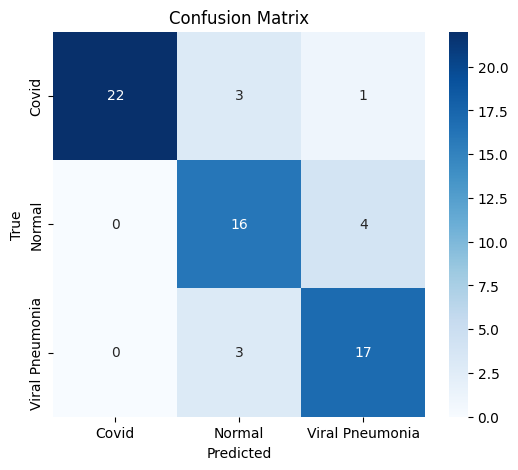

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Save the model

In [20]:
cnn_model.save(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Model\cnn_covid_model.keras")

In [126]:
saved_model = load_model(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Model\cnn_covid_model.keras")
loss, acc = saved_model.evaluate(test_dataset)
print("Loaded Model Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.7273 - loss: 0.6110
Loaded Model Accuracy: 0.7272727489471436


# Prediction 

In [23]:
#model = load_model(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Model\cnn_covid_model.keras")

class_names = [
                "Covid",
                "Normal",
                "Viral Pneumonia"
            ]

def predict_xray(img_path):
    img = image.load_img(img_path,target_size=(224,224))
    img = image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    pred = cnn_model.predict(img)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100
    print(f"Prediction: {class_names[pred_class]}")
    print(f"Confidence: {confidence:.2f}%")

predict_xray(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Data\Covid19-dataset\test\Covid\0100.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediction: Covid
Confidence: 94.95%


In [27]:
#model = load_model(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Model\cnn_covid_model.keras")

class_names = [
                "Covid",
                "Normal",
                "Viral Pneumonia"
            ]

def predict_xray(img_path):
    img = image.load_img(img_path,target_size=(224,224))
    img = image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    pred = cnn_model.predict(img)
    print(pred)
    print("Sum:", pred.sum())
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100
    print(f"Prediction: {class_names[pred_class]}")
    print(f"Confidence: {confidence:.2f}%")

predict_xray(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Images\Normal_sample.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[0.2788591  0.08904817 0.6320927 ]]
Sum: 1.0
Prediction: Viral Pneumonia
Confidence: 63.21%
